# Decision trees and random forests

A decision tree partitions feature space recursively. A random forest fits many randomized trees and combines their predictions. The experiment uses an interaction pattern that cannot be represented by one straight decision boundary.


## Gini impurity and split gain

For class proportions `p_k`, the Gini impurity is

```text
Gini = 1 - sum(p_k^2)
```

It is zero for a pure node. A candidate split is evaluated by the weighted impurity of its children, and the split with the greatest reduction is selected.


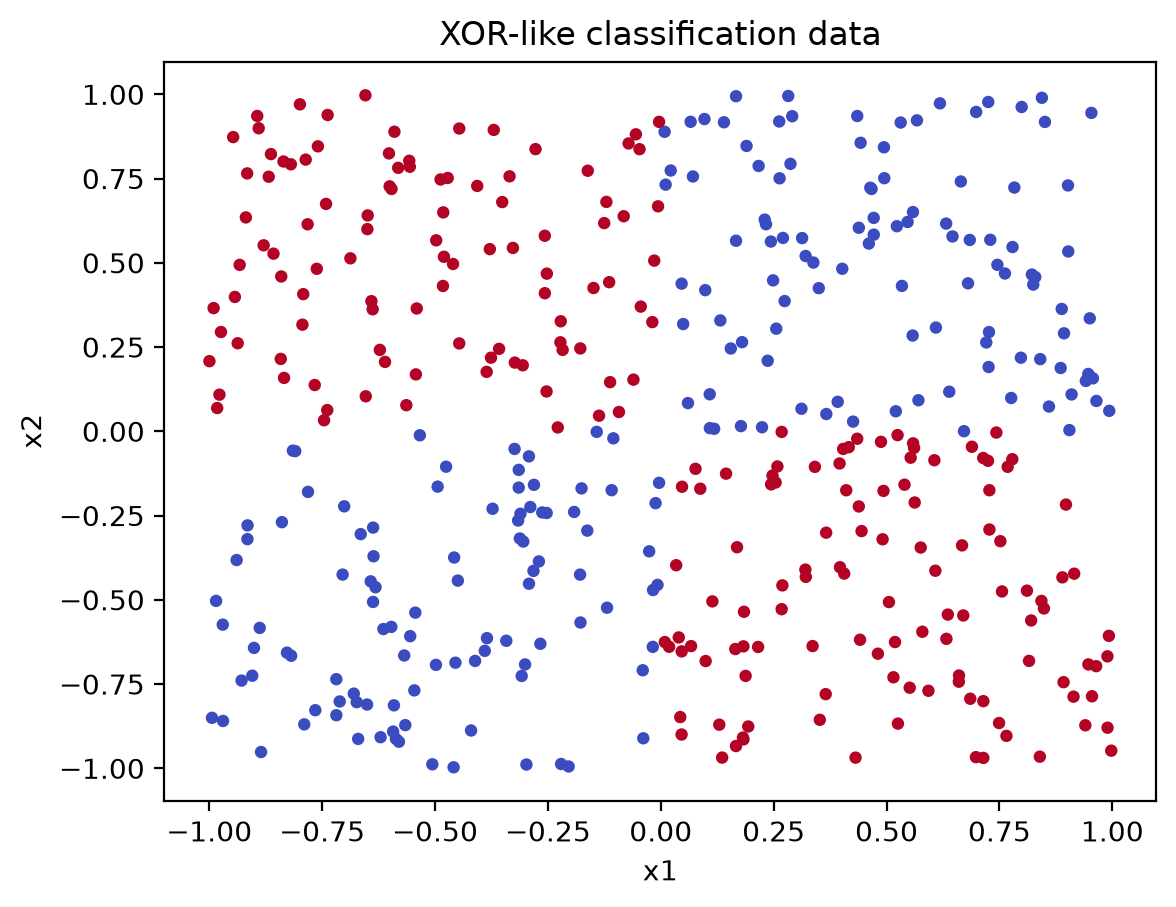

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(55)
X = rng.uniform(-1, 1, size=(600, 2))
y = (X[:, 0] * X[:, 1] < 0).astype(int)

order = rng.permutation(len(y))
train_idx, test_idx = order[:420], order[420:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=12)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('XOR-like classification data')
plt.show()

## Tree construction

Each node stores a majority-class prediction. If the stopping conditions are not met, the code searches for a feature and threshold, divides the data, and recursively builds the two child nodes. Prediction follows the stored thresholds until it reaches a leaf.


In [2]:
def gini(labels):
    if len(labels) == 0:
        return 0.0
    proportions = np.bincount(labels, minlength=2) / len(labels)
    return 1.0 - np.sum(proportions ** 2)

def best_split(X, y, features, min_samples):
    parent_impurity = gini(y)
    best = None

    for feature in features:
        values = np.unique(X[:, feature])
        thresholds = (values[:-1] + values[1:]) / 2
        for threshold in thresholds:
            left = X[:, feature] <= threshold
            n_left = left.sum()
            n_right = len(y) - n_left
            if n_left < min_samples or n_right < min_samples:
                continue

            child_impurity = (n_left / len(y)) * gini(y[left])
            child_impurity += (n_right / len(y)) * gini(y[~left])
            gain = parent_impurity - child_impurity
            if best is None or gain > best[0]:
                best = (gain, feature, threshold)

    return best

## Tree complexity

`max_depth` and `min_samples` limit how finely the tree can partition the data. Increasing depth can reduce training error while producing a boundary that follows individual observations. The train and test scores should be interpreted together.


In [3]:
def build_tree(X, y, depth, max_depth, min_samples, max_features, rng):
    counts = np.bincount(y, minlength=2)
    node = {'prediction': int(np.argmax(counts))}

    stop = (depth >= max_depth or len(y) < 2 * min_samples
            or np.unique(y).size == 1)
    if stop:
        return node

    features = rng.choice(X.shape[1], size=max_features, replace=False)
    split = best_split(X, y, features, min_samples)
    if split is None:
        return node

    _, feature, threshold = split
    left = X[:, feature] <= threshold
    node.update({
        'feature': int(feature),
        'threshold': float(threshold),
        'left': build_tree(X[left], y[left], depth + 1, max_depth,
                          min_samples, max_features, rng),
        'right': build_tree(X[~left], y[~left], depth + 1, max_depth,
                           min_samples, max_features, rng),
    })
    return node

def predict_one(node, point):
    while 'feature' in node:
        branch = 'left' if point[node['feature']] <= node['threshold'] else 'right'
        node = node[branch]
    return node['prediction']

def predict_tree(tree, X):
    return np.array([predict_one(tree, point) for point in X])

tree = build_tree(X_train, y_train, depth=0, max_depth=8,
                  min_samples=3, max_features=2, rng=rng)
print('tree train accuracy:', np.mean(predict_tree(tree, X_train) == y_train))
print('tree test accuracy:', np.mean(predict_tree(tree, X_test) == y_test))

tree train accuracy: 0.9976190476190476
tree test accuracy: 0.9944444444444445


## Random forest

Each tree receives a bootstrap sample. At each split it considers a random subset of features. These choices reduce correlation between the trees, so averaging their votes can reduce the variance of an individual deep tree.


tree train/test accuracy: 0.998 / 0.994
forest test accuracy:     1.000


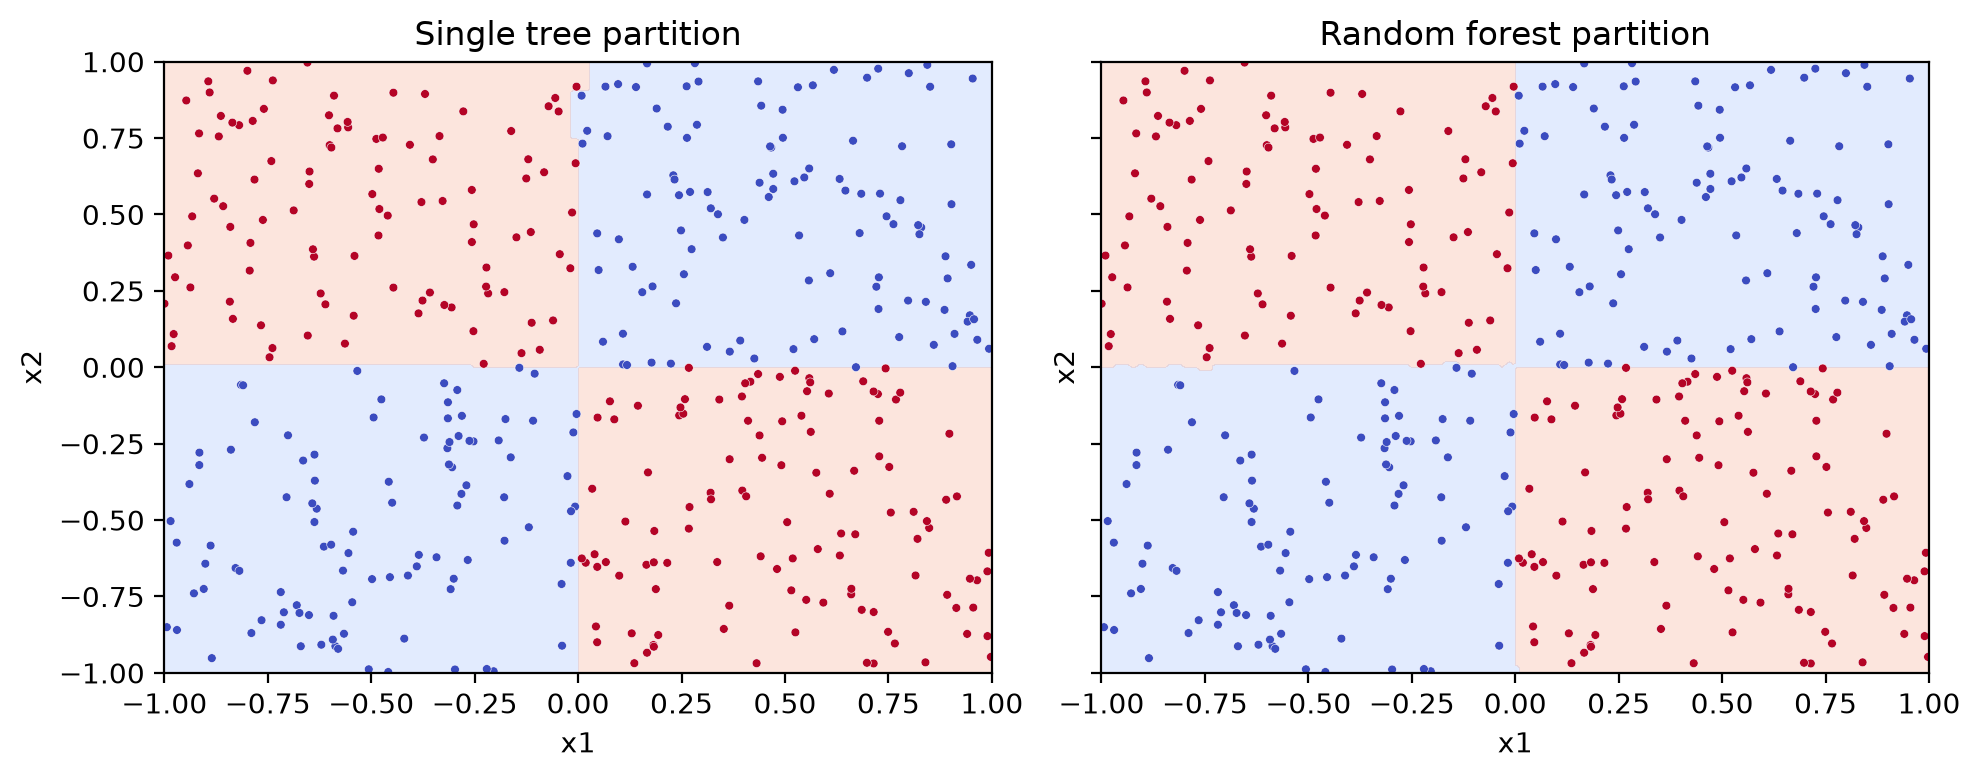

In [4]:
def fit_forest(X, y, n_trees=25, max_depth=8, min_samples=3, seed=0):
    forest_rng = np.random.default_rng(seed)
    trees = []
    max_features = max(1, int(np.sqrt(X.shape[1])))
    for _ in range(n_trees):
        bootstrap = forest_rng.integers(0, len(y), size=len(y))
        trees.append(build_tree(X[bootstrap], y[bootstrap], 0, max_depth, min_samples, max_features, forest_rng))
    return trees

def predict_forest(forest, X):
    votes = np.array([predict_tree(tree, X) for tree in forest])
    return (votes.mean(axis=0) >= 0.5).astype(int)

forest = fit_forest(X_train, y_train, n_trees=40, seed=4)
tree_prediction = predict_tree(tree, X_test)
forest_prediction = predict_forest(forest, X_test)
print(f'tree train/test accuracy: {np.mean(predict_tree(tree, X_train) == y_train):.3f} / {np.mean(tree_prediction == y_test):.3f}')
print(f'forest test accuracy:     {np.mean(forest_prediction == y_test):.3f}')

grid_x, grid_y = np.meshgrid(np.linspace(-1, 1, 220), np.linspace(-1, 1, 220))
grid = np.c_[grid_x.ravel(), grid_y.ravel()]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, title, prediction in [(axes[0], 'Single tree partition', predict_tree(tree, grid)), (axes[1], 'Random forest partition', predict_forest(forest, grid))]:
    ax.contourf(grid_x, grid_y, prediction.reshape(grid_x.shape), levels=[-0.5, 0.5, 1.5], cmap='coolwarm', alpha=0.25)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=10, edgecolor='white', linewidth=0.2)
    ax.set(title=title, xlabel='x1', ylabel='x2')
fig.tight_layout()
plt.show()


## Decision maps

The final figure shows the partition from one tree and the averaged partition from the forest. The forest is usually less dependent on one sequence of splits, although the model gives up some of the direct interpretability of a single tree.
